# 05 — Análise por DDD

**Objetivo:** avaliar se o DDD do telefone é uma variável discriminatória para
identificar telefones com alta taxa de leitura (`read`). Para cada DDD,
estimamos `P(telefone alta_perf | DDD)` com intervalo de confiança de Wilson e
verificamos se há DDDs com concentração significativamente maior de telefones
de alta performance.

Trabalhamos a partir de `disparos_sistema.parquet`, gerado pelo
notebook `01_preprocessing.ipynb`.

## Roteiro
1. Construir métrica de **alta performance** por telefone (≥ 90 % de `read`).
2. Estimar `P(alta_perf | DDD)` com IC de Wilson para cada DDD.
3. Analisar a **distribuição de volume e incerteza** por DDD.
4. Filtrar DDDs com **estimativas confiáveis** (erro ≤ 10 %) e visualizar.

## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from statsmodels.stats.proportion import proportion_confint

OUT_DIR = Path('../outputs/processed')

df_disparos_sistema = pd.read_parquet(OUT_DIR / 'disparos_sistema.parquet')
print(f'df_disparos_sistema: {df_disparos_sistema.shape}')


df_disparos_sistema: (748675, 20)


## 1. Métrica de alta performance por telefone
Definimos como **telefone de alta performance** aquele cuja taxa de `read` é ≥ 90 %.
Agrupamos por `(telefone_numero, telefone_ddd)` para associar cada telefone ao
seu DDD.

In [2]:
LIMIAR_BOM = 0.9

df_tel_read = (
    df_disparos_sistema
    .assign(read=lambda x: (x['status_disparo'] == 'read').astype(int))
    .groupby(['telefone_numero',
              'telefone_ddd'])
    .agg(total_envios=('read', 'count'), reads=('read', 'sum'))
    .reset_index()
)
df_tel_read['taxa_read'] = df_tel_read['reads'] / df_tel_read['total_envios']
df_tel_read['alta_perf'] = (df_tel_read['taxa_read'] >= LIMIAR_BOM).astype(int)

df_tel_read.head()

,telefone_numero,telefone_ddd,total_envios,reads,taxa_read,alta_perf
0,10000135852850332451,17265310353192282774,6,6,1.0,1
1,10000156218966059013,17265310353192282774,2,2,1.0,1
2,10000201787338295860,17265310353192282774,1,1,1.0,1
3,10000226489572032674,17265310353192282774,2,2,1.0,1
4,10000343406836092322,17265310353192282774,2,0,0.0,0


## 2. Proporção de alta performance por DDD (IC de Wilson)
Para cada DDD estimamos `P(telefone alta_perf | DDD)` com intervalo de confiança
de Wilson.

In [3]:
def adiciona_ic_wilson(df: pd.DataFrame, count_col: str, total_col: str,
                       prefix: str = '') -> pd.DataFrame:
    """Adiciona colunas ci_low/ci_high a partir de contagens."""
    lows, highs = [], []
    for _, row in df.iterrows():
        low, high = proportion_confint(row[count_col], row[total_col], method='wilson')
        lows.append(low)
        highs.append(high)
    df[f'{prefix}ci_low'] = lows
    df[f'{prefix}ci_high'] = highs
    return df


df_ddd = (
    df_tel_read
    .groupby('telefone_ddd')
    .agg(qtd_telefones=('telefone_numero', 'nunique'),
         telefones_alta_perf=('alta_perf', 'sum'))
    .reset_index()
)
df_ddd['prob_alta_perf'] = df_ddd['telefones_alta_perf'] / df_ddd['qtd_telefones']
df_ddd = adiciona_ic_wilson(df_ddd, 'telefones_alta_perf', 'qtd_telefones')
df_ddd['erro'] = df_ddd['ci_high'] - df_ddd['prob_alta_perf']

print(f'Total de DDDs: {df_ddd.shape[0]}')

Total de DDDs: 67


## 3. Distribuição de volume e incerteza por DDD

In [4]:
df_ddd.sort_values(by='qtd_telefones', ascending=False).head(20)

,telefone_ddd,qtd_telefones,telefones_alta_perf,prob_alta_perf,ci_low,ci_high,erro
28,17265310353192282774,248973,178704,0.717765,0.715993,0.719529,0.001765
2,1110362451252208393,794,524,0.659950,0.626299,0.692060,0.032110
23,15846025020102267254,356,228,0.640449,0.589346,0.688554,0.048104
54,6906343888316397859,270,163,0.603704,0.544298,0.660199,0.056496
11,13922839047927264535,188,127,0.675532,0.605674,0.738360,0.062828
39,2685248380958544781,174,128,0.735632,0.665529,0.795556,0.059923
64,9525433826999338114,148,83,0.560811,0.480319,0.638225,0.077415
5,12707868701227488886,102,58,0.568627,0.471750,0.660524,0.091896
9,13185225668871621484,101,62,0.613861,0.516402,0.702977,0.089115
20,15468730639809407528,92,58,0.630435,0.528430,0.721984,0.091549


### 3.1. Volume de telefones por DDD

In [5]:
print("Menor volume:")
print(df_ddd.nsmallest(1, 'qtd_telefones')[['telefone_ddd', 'qtd_telefones']])

print("\nMaior volume:")
print(df_ddd.nlargest(1, 'qtd_telefones')[['telefone_ddd', 'qtd_telefones']])

Menor volume:
           telefone_ddd  qtd_telefones
42  3477629532570627175              2

Maior volume:
            telefone_ddd  qtd_telefones
28  17265310353192282774         248973


### 3.2. Distribuição do erro das estimativas

In [6]:
df_ddd['erro'].describe()

count    67.000000
mean      0.184788
std       0.097899
min       0.001765
25%       0.115400
50%       0.161318
75%       0.246621
max       0.459007
Name: erro, dtype: float64

> **Observação:** a discrepância entre DDDs é muito grande, e muitos DDDs possuem volume de dados insuficiente para estimativas confiáveis. Aplicaremos um filtro de erro máximo na próxima seção.

## 4. DDDs com estimativas confiáveis (erro ≤ 10 %)
Filtramos apenas os DDDs cujo erro do IC de Wilson não excede 10 % para
garantir estimativas minimamente confiáveis.

DDDs após filtro: 12


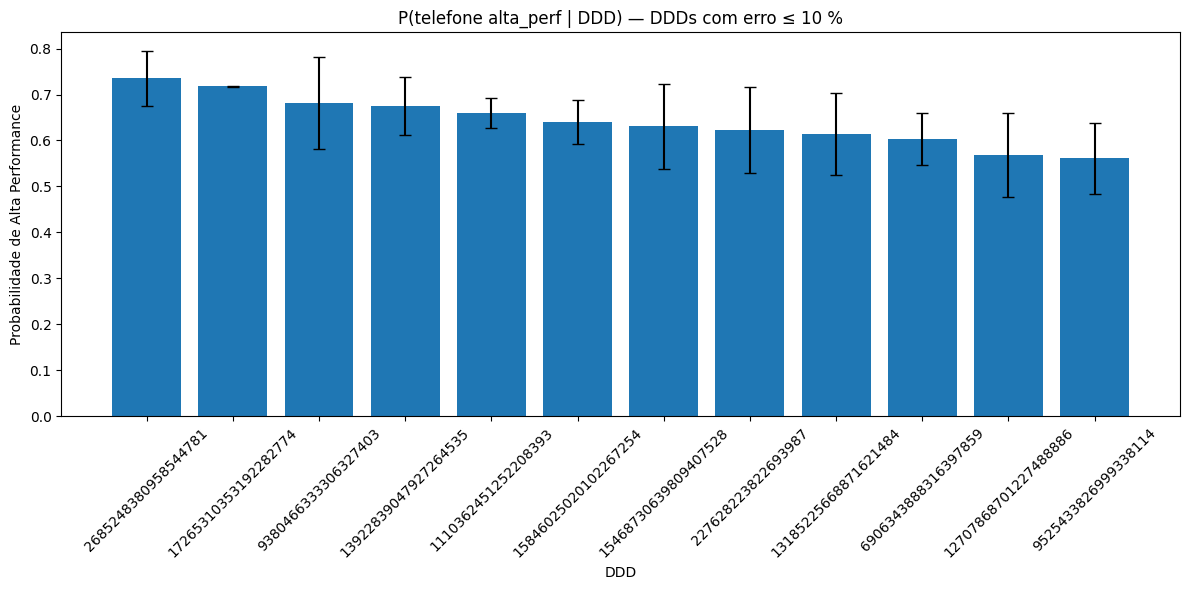

In [7]:
df_filtrado = df_ddd[df_ddd['erro'] <= 0.1].copy()
print(f"DDDs após filtro: {df_filtrado.shape[0]}")

df_filtrado = df_filtrado.sort_values('prob_alta_perf', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(
    df_filtrado['telefone_ddd'].astype(str),
    df_filtrado['prob_alta_perf'],
    yerr=df_filtrado['erro'],
    capsize=4
)
plt.xticks(rotation=45)
plt.xlabel('DDD')
plt.ylabel('Probabilidade de Alta Performance')
plt.title('P(telefone alta_perf | DDD) — DDDs com erro ≤ 10 %')
plt.tight_layout()
plt.show()

## 5. Taxa de leitura por CPF

Carrega `cpf_telefones.parquet` (gerado em `01_preprocessing.ipynb`), que já
inclui, em cada linha, o volume de envios e leituras acumulado do CPF
(`total_envios_cpf`, `total_reads_cpf`, `taxa_read_cpf`). Como esses valores
são constantes por CPF, deduplicamos para obter **uma linha por CPF** e
analisamos a distribuição da taxa de leitura.

In [ ]:
df_cpf_telefones = pd.read_parquet(OUT_DIR / 'cpf_telefones.parquet')

# 1 linha por CPF — taxa_read_cpf é constante por CPF
df_taxa_cpf = (
    df_cpf_telefones
    .dropna(subset=['taxa_read_cpf'])
    .drop_duplicates(subset=['cpf'])
    [['cpf', 'total_envios_cpf', 'total_reads_cpf', 'taxa_read_cpf']]
    .reset_index(drop=True)
)

print(f'CPFs únicos no dataset .........: {df_cpf_telefones["cpf"].nunique():,}')
print(f'CPFs com pelo menos 1 disparo ..: {len(df_taxa_cpf):,}')
print('\nEstatísticas de taxa_read_cpf:')
display(df_taxa_cpf['taxa_read_cpf'].describe().round(4))

print('\nEstatísticas de total_envios_cpf:')
display(df_taxa_cpf['total_envios_cpf'].describe().round(2))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_taxa_cpf['taxa_read_cpf'], bins=20, edgecolor='black')
axes[0].set_xlabel('taxa_read_cpf')
axes[0].set_ylabel('Quantidade de CPFs')
axes[0].set_title('Distribuição da taxa de leitura por CPF')

# CPFs com volume mínimo (≥ 3 envios) — taxa fica mais estável
df_filtro = df_taxa_cpf[df_taxa_cpf['total_envios_cpf'] >= 3]
axes[1].hist(df_filtro['taxa_read_cpf'], bins=20, edgecolor='black', color='orange')
axes[1].set_xlabel('taxa_read_cpf')
axes[1].set_title(f'CPFs com ≥ 3 envios (n = {len(df_filtro):,})')

plt.tight_layout()
plt.show()

print(f'Taxa média de leitura por CPF (todos)        : {df_taxa_cpf["taxa_read_cpf"].mean():.4f}')
print(f'Taxa média de leitura por CPF (≥ 3 envios)   : {df_filtro["taxa_read_cpf"].mean():.4f}')
print(f'CPFs com taxa = 100%                         : {(df_taxa_cpf["taxa_read_cpf"] == 1.0).sum():,}')
print(f'CPFs com taxa = 0%                           : {(df_taxa_cpf["taxa_read_cpf"] == 0.0).sum():,}')

## Conclusão

O DDD apresenta **baixo poder discriminatório**, com diferenças entre grupos pouco robustas devido à alta incerteza das estimativas. A mediana do erro é de aproximadamente 16%, indicando elevada variabilidade, especialmente em DDDs com menor volume de dados, o que reduz a confiabilidade dessa variável como critério de decisão.

**Implicação para o scoring:** o DDD não foi incluído como feature no algoritmo de escolha de telefones por GPS. 